# Data Preparation

Download the CUB-200-2011 dataset, build a focused 20-species subset,
and run all preparation steps (inspection, label verification,
corrupted-image detection, and class-balance analysis) on that subset.

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("wenewone/cub2002011")

print("Path to dataset files:", path)

100%|██████████| 1.49G/1.49G [00:14<00:00, 112MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/wenewone/cub2002011/versions/7


## 1. Dataset Setup

The downloaded dataset path is converted to a `Path` object and the main
CUB-200-2011 root folder is located.

In [2]:
from pathlib import Path
import os
import shutil

# Convert the downloaded dataset path into a Path object
dataset_path = Path(path)

print("Dataset path:", dataset_path)
print("Dataset exists:", dataset_path.exists())

print("\nFiles and folders inside the dataset:")
for item in sorted(dataset_path.iterdir()):
    if item.is_dir():
        print("[Folder]", item.name)
    else:
        print("[File]", item.name)

Dataset path: /root/.cache/kagglehub/datasets/wenewone/cub2002011/versions/7
Dataset exists: True

Files and folders inside the dataset:
[Folder] CUB_200_2011
[Folder] cvpr2016_cub
[Folder] segmentations


In [3]:
# Select the main CUB-200-2011 dataset folder
DATASET_ROOT   = dataset_path / "CUB_200_2011"
IMAGES_FOLDER  = DATASET_ROOT / "images"

print("Dataset root:", DATASET_ROOT)
print("Images folder exists:", IMAGES_FOLDER.exists())

print("\nFiles and folders inside CUB_200_2011:")
for item in sorted(DATASET_ROOT.iterdir()):
    print("-", item.name)

Dataset root: /root/.cache/kagglehub/datasets/wenewone/cub2002011/versions/7/CUB_200_2011
Images folder exists: True

Files and folders inside CUB_200_2011:
- README
- attributes
- bounding_boxes.txt
- classes.txt
- image_class_labels.txt
- images
- images.txt
- parts
- train_test_split.txt


## 2. Build the 20-Species Subset

Before any analysis begins, the first 20 bird-species folders are copied
from the full dataset into a dedicated subset directory. Every subsequent
step in this notebook operates exclusively on this subset.

In [4]:
# Destination directory for the 20-species subset
SUBSET_DIR            = "./dataset_20_species"
SUBSET_IMAGES_FOLDER  = Path(SUBSET_DIR)

# Remove any existing subset directory and start fresh
if os.path.exists(SUBSET_DIR):
    shutil.rmtree(SUBSET_DIR)
os.makedirs(SUBSET_DIR)

# Select the first 20 species folders (sorted alphabetically)
species_folders  = sorted([f for f in IMAGES_FOLDER.iterdir() if f.is_dir()])
selected_species = species_folders[:20]

# Copy each selected species folder into the subset directory
for species_path in selected_species:
    dst = os.path.join(SUBSET_DIR, species_path.name)
    shutil.copytree(str(species_path), dst)

print(f"20-species subset created at: {SUBSET_DIR}")
print(f"Number of species included:   {len(selected_species)}")
print("\nSpecies included:")
for species_path in selected_species:
    print(f"  - {species_path.name}")

20-species subset created at: ./dataset_20_species
Number of species included:   20

Species included:
  - 001.Black_footed_Albatross
  - 002.Laysan_Albatross
  - 003.Sooty_Albatross
  - 004.Groove_billed_Ani
  - 005.Crested_Auklet
  - 006.Least_Auklet
  - 007.Parakeet_Auklet
  - 008.Rhinoceros_Auklet
  - 009.Brewer_Blackbird
  - 010.Red_winged_Blackbird
  - 011.Rusty_Blackbird
  - 012.Yellow_headed_Blackbird
  - 013.Bobolink
  - 014.Indigo_Bunting
  - 015.Lazuli_Bunting
  - 016.Painted_Bunting
  - 017.Cardinal
  - 018.Spotted_Catbird
  - 019.Gray_Catbird
  - 020.Yellow_breasted_Chat


## 3. Dataset Inspection

The 20-species subset folders and image counts are examined to confirm
the subset was assembled correctly.

In [5]:
print("Subset path:", SUBSET_IMAGES_FOLDER)
print("Subset exists:", SUBSET_IMAGES_FOLDER.exists())

print("\nFolders inside the subset:")
for item in sorted(SUBSET_IMAGES_FOLDER.iterdir()):
    if item.is_dir():
        image_count = sum(
            1 for f in item.iterdir()
            if f.suffix.lower() in (".jpg", ".jpeg", ".png")
        )
        print(f"  [Folder] {item.name}  ({image_count} images)")

Subset path: dataset_20_species
Subset exists: True

Folders inside the subset:
  [Folder] 001.Black_footed_Albatross  (60 images)
  [Folder] 002.Laysan_Albatross  (60 images)
  [Folder] 003.Sooty_Albatross  (58 images)
  [Folder] 004.Groove_billed_Ani  (60 images)
  [Folder] 005.Crested_Auklet  (44 images)
  [Folder] 006.Least_Auklet  (41 images)
  [Folder] 007.Parakeet_Auklet  (53 images)
  [Folder] 008.Rhinoceros_Auklet  (48 images)
  [Folder] 009.Brewer_Blackbird  (60 images)
  [Folder] 010.Red_winged_Blackbird  (60 images)
  [Folder] 011.Rusty_Blackbird  (60 images)
  [Folder] 012.Yellow_headed_Blackbird  (56 images)
  [Folder] 013.Bobolink  (60 images)
  [Folder] 014.Indigo_Bunting  (60 images)
  [Folder] 015.Lazuli_Bunting  (58 images)
  [Folder] 016.Painted_Bunting  (58 images)
  [Folder] 017.Cardinal  (57 images)
  [Folder] 018.Spotted_Catbird  (45 images)
  [Folder] 019.Gray_Catbird  (59 images)
  [Folder] 020.Yellow_breasted_Chat  (59 images)


## 4. Check Dataset Labels

The dataset label files are loaded from the full CUB-200-2011 metadata
and filtered to retain only the 20 selected species. The filtered records
are then checked for missing labels, duplicate IDs, and invalid class IDs.

In [6]:
import pandas as pd

# File containing class IDs and bird species names
classes = pd.read_csv(
    DATASET_ROOT / "classes.txt",
    sep=r"\s+",
    names=["class_id", "class_name"]
)

# File containing image IDs and image paths
images = pd.read_csv(
    DATASET_ROOT / "images.txt",
    sep=r"\s+",
    names=["image_id", "image_path"]
)

# File connecting every image ID to a class ID
image_labels = pd.read_csv(
    DATASET_ROOT / "image_class_labels.txt",
    sep=r"\s+",
    names=["image_id", "class_id"]
)

# Names of the 20 selected species (folder name == class_name in this dataset)
selected_species_names = [p.name for p in selected_species]

# Keep only the classes that belong to the 20-species subset
classes_subset = classes[
    classes["class_name"].isin(selected_species_names)
].copy()

print("Total classes in full dataset:", len(classes))
print("Classes retained in subset:",    len(classes_subset))

Total classes in full dataset: 200
Classes retained in subset: 20


In [7]:
print("20-species subset classes:")
display(classes_subset)

20-species subset classes:


,class_id,class_name
0,1,001.Black_footed_Albatross
1,2,002.Laysan_Albatross
2,3,003.Sooty_Albatross
3,4,004.Groove_billed_Ani
4,5,005.Crested_Auklet
5,6,006.Least_Auklet
6,7,007.Parakeet_Auklet
7,8,008.Rhinoceros_Auklet
8,9,009.Brewer_Blackbird
9,10,010.Red_winged_Blackbird


In [8]:
# Combine image paths, class IDs, and class names into one table
dataset_info = images.merge(
    image_labels,
    on="image_id",
    how="left"
)

dataset_info = dataset_info.merge(
    classes,
    on="class_id",
    how="left"
)

# Filter to the 20 selected species only
dataset_info = dataset_info[
    dataset_info["class_name"].isin(selected_species_names)
].copy()

dataset_info.reset_index(drop=True, inplace=True)

print("Subset dataset shape:", dataset_info.shape)
display(dataset_info.head(10))

Subset dataset shape: (1115, 4)


,image_id,image_path,class_id,class_name
0,1,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross
1,2,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross
2,3,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross
3,4,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross
4,5,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross
5,6,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross
6,7,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross
7,8,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross
8,9,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross
9,10,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross


In [9]:
# Count missing values in each column
print("Missing values:")
print(dataset_info.isnull().sum())

# Check whether any image ID appears more than once
duplicate_image_ids = dataset_info["image_id"].duplicated().sum()

# Check whether any image path appears more than once
duplicate_image_paths = dataset_info["image_path"].duplicated().sum()

# Check whether class IDs are within the expected range for the subset
valid_class_ids = classes_subset["class_id"].tolist()
invalid_class_ids = dataset_info[
    ~dataset_info["class_id"].isin(valid_class_ids)
]

print("\nDuplicate image IDs:",  duplicate_image_ids)
print("Duplicate image paths:", duplicate_image_paths)
print("Invalid class IDs:",     len(invalid_class_ids))

Missing values:
image_id      0
image_path    0
class_id      0
class_name    0
dtype: int64

Duplicate image IDs: 0
Duplicate image paths: 0
Invalid class IDs: 0


In [10]:
# Extract the folder name from each image path
# Example:
# 001.Black_footed_Albatross/image_001.jpg
# becomes:
# 001.Black_footed_Albatross

dataset_info["folder_name"] = dataset_info["image_path"].apply(
    lambda image_path: Path(image_path).parts[0]
)

# Find rows where the folder name and official class name do not match
label_mismatches = dataset_info[
    dataset_info["folder_name"] != dataset_info["class_name"]
]

print("Total images checked:",    len(dataset_info))
print("Folder-label mismatches:", len(label_mismatches))

if len(label_mismatches) == 0:
    print("Result: All image folders match their official class labels.")
else:
    print("Images with mismatched labels:")
    display(label_mismatches.head(10))

Total images checked: 1115
Folder-label mismatches: 0
Result: All image folders match their official class labels.


In [11]:
# Build the full image path pointing to the SUBSET directory
dataset_info["full_image_path"] = dataset_info["image_path"].apply(
    lambda image_path: SUBSET_IMAGES_FOLDER / image_path
)

# Check whether every listed image exists in the subset folder
dataset_info["file_exists"] = dataset_info["full_image_path"].apply(
    lambda image_path: image_path.exists()
)

missing_image_files = dataset_info[
    dataset_info["file_exists"] == False
]

print("Images listed in metadata:", len(dataset_info))
print("Existing image files:",       dataset_info["file_exists"].sum())
print("Missing image files:",        len(missing_image_files))

if len(missing_image_files) == 0:
    print("Result: Every image listed in the metadata exists in the subset folder.")
else:
    display(missing_image_files.head(10))

Images listed in metadata: 1115
Existing image files: 1115
Missing image files: 0
Result: Every image listed in the metadata exists in the subset folder.


### Label Verification Conclusion

The 20-species subset was verified against the CUB-200-2011 metadata files.
No missing labels, duplicate image IDs, duplicate image paths, or invalid
class IDs were found. Every image listed in the filtered metadata exists
in the subset folder.

## 5. Detect Corrupted and Duplicate Images

Each image in the 20-species subset is opened and verified to identify
corrupted or unreadable files. Exact duplicate images are detected using
their SHA-256 file hashes. The original subset is preserved, and invalid
or duplicate records are excluded from a clean dataset table.

In [12]:
from PIL import Image
from tqdm.auto import tqdm

def validate_image(image_path):
    """
    Check whether an image can be opened, verified and converted to RGB.
    """
    try:
        # Verify the image file structure
        with Image.open(image_path) as image:
            image.verify()

        # Open it again and check that pixel data can be loaded
        with Image.open(image_path) as image:
            image.convert("RGB").load()

        return True, ""

    except Exception as error:
        return False, str(error)


validation_results = []

for image_path in tqdm(
    dataset_info["full_image_path"],
    desc="Checking image files"
):
    is_valid, error_message = validate_image(image_path)

    validation_results.append({
        "is_valid_image":   is_valid,
        "validation_error": error_message
    })

validation_results = pd.DataFrame(validation_results)

dataset_info["is_valid_image"]   = validation_results["is_valid_image"]
dataset_info["validation_error"] = validation_results["validation_error"]

corrupted_images = dataset_info[
    dataset_info["is_valid_image"] == False
]

print("Total images checked:",             len(dataset_info))
print("Valid images:",                      dataset_info["is_valid_image"].sum())
print("Corrupted or unreadable images:",   len(corrupted_images))

if len(corrupted_images) == 0:
    print("Result: No corrupted images were found.")
else:
    display(
        corrupted_images[
            ["image_id", "image_path", "class_name", "validation_error"]
        ].head(10)
    )

Checking image files:   0%|          | 0/1115 [00:00<?, ?it/s]

Total images checked: 1115
Valid images: 1115
Corrupted or unreadable images: 0
Result: No corrupted images were found.


In [13]:
import hashlib

def calculate_file_hash(image_path, chunk_size=8192):
    """
    Calculate a SHA-256 hash from the image file contents.
    Identical files will produce the same hash.
    """
    sha256 = hashlib.sha256()

    with open(image_path, "rb") as image_file:
        while True:
            data = image_file.read(chunk_size)

            if not data:
                break

            sha256.update(data)

    return sha256.hexdigest()


image_hashes = []

for image_path, is_valid in tqdm(
    zip(
        dataset_info["full_image_path"],
        dataset_info["is_valid_image"]
    ),
    total=len(dataset_info),
    desc="Calculating image hashes"
):
    if is_valid:
        image_hashes.append(calculate_file_hash(image_path))
    else:
        image_hashes.append(None)

dataset_info["file_hash"] = image_hashes

# Keep the first copy and mark later identical files as duplicates
dataset_info["is_exact_duplicate"] = (
    dataset_info["file_hash"].notna()
    & dataset_info["file_hash"].duplicated(keep="first")
)

duplicate_images = dataset_info[
    dataset_info["is_exact_duplicate"] == True
]

print("Total valid images:",    dataset_info["is_valid_image"].sum())
print("Exact duplicate images:", len(duplicate_images))

if len(duplicate_images) == 0:
    print("Result: No exact duplicate images were found.")
else:
    print("Duplicate images that will be excluded:")
    display(
        duplicate_images[
            ["image_id", "image_path", "class_name", "file_hash"]
        ].head(10)
    )

Calculating image hashes:   0%|          | 0/1115 [00:00<?, ?it/s]

Total valid images: 1115
Exact duplicate images: 0
Result: No exact duplicate images were found.


In [14]:
clean_dataset_info = dataset_info[
    (dataset_info["is_valid_image"]    == True)
    & (dataset_info["is_exact_duplicate"] == False)
].copy()

clean_dataset_info.reset_index(drop=True, inplace=True)

removed_corrupted = len(
    dataset_info[dataset_info["is_valid_image"] == False]
)

removed_duplicates = len(
    dataset_info[dataset_info["is_exact_duplicate"] == True]
)

print("Original number of images:", len(dataset_info))
print("Corrupted images excluded:", removed_corrupted)
print("Duplicate images excluded:", removed_duplicates)
print("Clean dataset size:",        len(clean_dataset_info))

Original number of images: 1115
Corrupted images excluded: 0
Duplicate images excluded: 0
Clean dataset size: 1115


In [15]:
# Get the hash values that appear more than once
duplicate_hashes = dataset_info.loc[
    dataset_info["file_hash"].duplicated(keep=False),
    "file_hash"
].unique()

# Display every image sharing a duplicate hash
duplicate_groups = dataset_info[
    dataset_info["file_hash"].isin(duplicate_hashes)
][
    ["image_id", "image_path", "class_id", "class_name", "file_hash"]
].sort_values("file_hash")

print("Number of duplicate groups:",      len(duplicate_hashes))
print("Images involved in duplicate groups:", len(duplicate_groups))

display(duplicate_groups)

Number of duplicate groups: 0
Images involved in duplicate groups: 0


,image_id,image_path,class_id,class_name,file_hash


In [16]:
duplicate_class_check = (
    duplicate_groups
    .groupby("file_hash")["class_id"]
    .nunique()
)

cross_class_duplicates = duplicate_class_check[
    duplicate_class_check > 1
]

print(
    "Duplicate groups containing images from different classes:",
    len(cross_class_duplicates)
)

if len(cross_class_duplicates) == 0:
    print("Result: The duplicate images belong to the same bird class.")
else:
    print("Warning: An identical image appears under different class labels.")

Duplicate groups containing images from different classes: 0
Result: The duplicate images belong to the same bird class.


### Image Quality and Duplicate Check Conclusion

All images in the 20-species subset were opened and verified successfully.
SHA-256 file hashes were computed to detect exact duplicates. Any corrupted
or duplicate images are excluded from the clean dataset table. The original
subset folder is left untouched.

## 6. Class Distribution and Balance

The number of clean images in each of the 20 bird-species classes is
examined to determine whether class balancing is necessary. Balancing
will only be applied if there is a meaningful difference between class sizes.

In [17]:
# Count valid and unique images in each bird class
class_distribution = (
    clean_dataset_info
    .groupby(["class_id", "class_name"])
    .size()
    .reset_index(name="image_count")
    .sort_values("image_count")
)

minimum_count  = class_distribution["image_count"].min()
maximum_count  = class_distribution["image_count"].max()
average_count  = class_distribution["image_count"].mean()
imbalance_ratio = maximum_count / minimum_count

print("Number of classes:",            len(class_distribution))
print("Minimum images in one class:",  minimum_count)
print("Maximum images in one class:",  maximum_count)
print("Average images per class:",     round(average_count, 2))
print("Imbalance ratio:",              round(imbalance_ratio, 3))

print("\nClasses with the fewest images:")
display(class_distribution.head(10))

print("\nClasses with the most images:")
display(class_distribution.tail(10))

Number of classes: 20
Minimum images in one class: 41
Maximum images in one class: 60
Average images per class: 55.75
Imbalance ratio: 1.463

Classes with the fewest images:


,class_id,class_name,image_count
5,6,006.Least_Auklet,41
4,5,005.Crested_Auklet,44
17,18,018.Spotted_Catbird,45
7,8,008.Rhinoceros_Auklet,48
6,7,007.Parakeet_Auklet,53
11,12,012.Yellow_headed_Blackbird,56
16,17,017.Cardinal,57
2,3,003.Sooty_Albatross,58
15,16,016.Painted_Bunting,58
14,15,015.Lazuli_Bunting,58



Classes with the most images:


,class_id,class_name,image_count
8,9,009.Brewer_Blackbird,59
18,19,019.Gray_Catbird,59
19,20,020.Yellow_breasted_Chat,59
1,2,002.Laysan_Albatross,60
3,4,004.Groove_billed_Ani,60
0,1,001.Black_footed_Albatross,60
12,13,013.Bobolink,60
13,14,014.Indigo_Bunting,60
9,10,010.Red_winged_Blackbird,60
10,11,011.Rusty_Blackbird,60


In [18]:
# Show how many classes have each possible number of images
count_frequency = (
    class_distribution["image_count"]
    .value_counts()
    .sort_index()
    .reset_index()
)

count_frequency.columns = [
    "images_per_class",
    "number_of_classes"
]

display(count_frequency)

,images_per_class,number_of_classes
0,41,1
1,44,1
2,45,1
3,48,1
4,53,1
5,56,1
6,57,1
7,58,3
8,59,3
9,60,7


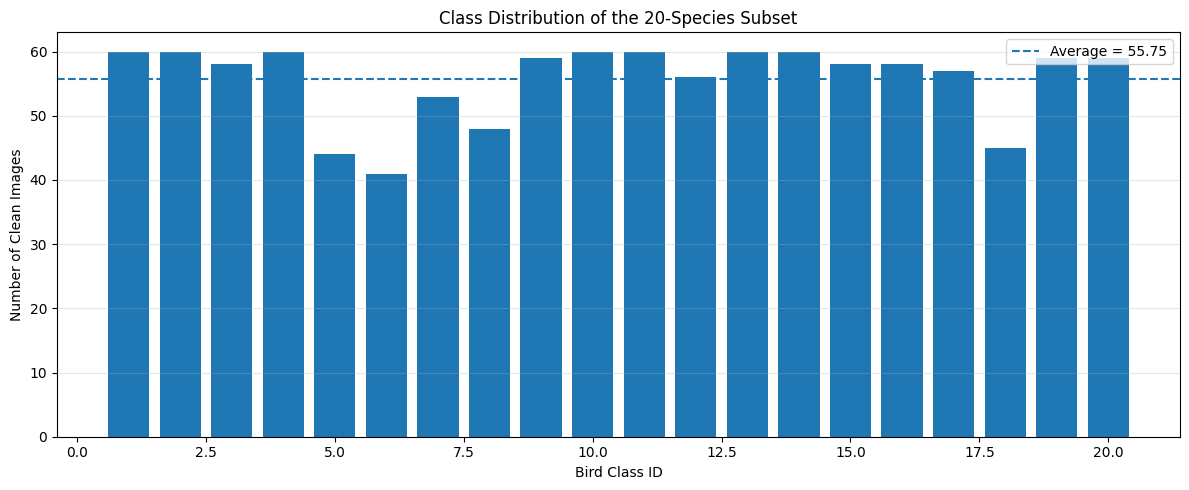

In [19]:
import matplotlib.pyplot as plt

plot_distribution = class_distribution.sort_values("class_id")

plt.figure(figsize=(12, 5))

plt.bar(
    plot_distribution["class_id"],
    plot_distribution["image_count"]
)

plt.axhline(
    average_count,
    linestyle="--",
    label=f"Average = {average_count:.2f}"
)

plt.xlabel("Bird Class ID")
plt.ylabel("Number of Clean Images")
plt.title("Class Distribution of the 20-Species Subset")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
# A ratio close to 1 means that the classes have similar sizes.
# We avoid balancing when the difference is small because undersampling
# would unnecessarily discard useful images.

if imbalance_ratio <= 1.5:
    balancing_required = False

    print("Balancing required: No")
    print(
        "Reason: The class sizes are sufficiently similar, "
        "so balancing would unnecessarily remove useful images."
    )
    print(
        "Decision: Keep all clean images and use a stratified "
        "training/testing split later."
    )
else:
    balancing_required = True

    print("Balancing required: Yes")
    print(
        "Reason: There is a considerable difference between "
        "the smallest and largest classes."
    )

Balancing required: No
Reason: The class sizes are sufficiently similar, so balancing would unnecessarily remove useful images.
Decision: Keep all clean images and use a stratified training/testing split later.


In [21]:
# No resampling is performed when the dataset is sufficiently balanced.
# The cleaned dataset becomes the final prepared dataset.

if not balancing_required:
    final_dataset_info = clean_dataset_info.copy()
else:
    # Keep the clean dataset temporarily.
    # A balancing method should only be chosen after team agreement.
    final_dataset_info = clean_dataset_info.copy()

final_dataset_info.reset_index(drop=True, inplace=True)

print("Clean dataset size:",         len(clean_dataset_info))
print("Final prepared dataset size:", len(final_dataset_info))
print("Number of final classes:",     final_dataset_info["class_id"].nunique())

Clean dataset size: 1115
Final prepared dataset size: 1115
Number of final classes: 20


### Class-Balance Conclusion

The 20-species subset class-distribution analysis showed whether the class
sizes are sufficiently similar. If the imbalance ratio is at or below 1.5,
no undersampling or oversampling is applied — all clean images are retained
and a stratified training/testing split will be used later to preserve
class representation.

In [22]:
# Keep only portable columns.
# Do not save full_image_path because it contains a local machine path.

columns_to_save = [
    "image_id",
    "image_path",
    "class_id",
    "class_name"
]

prepared_metadata = final_dataset_info[
    columns_to_save
].copy()

output_file = "/content/clean_dataset_metadata.csv"
prepared_metadata.to_csv(output_file, index=False)

print("Metadata saved to:", output_file)
print("Saved rows:",        len(prepared_metadata))

display(prepared_metadata.head())

Metadata saved to: /content/clean_dataset_metadata.csv
Saved rows: 1115


,image_id,image_path,class_id,class_name
0,1,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross
1,2,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross
2,3,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross
3,4,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross
4,5,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross


## 7. Dataset Preprocessing (Phase 2)

In this section, we implement the dataset preprocessing phase. This covers all required preprocessing tasks:
1. **Resize images**: Resize all bird images to a standard shape ($224 \times 224$ pixels).
2. **Normalize images**: Rescale pixel intensities to the $[0.0, 1.0]$ range.
3. **Train/Validation/Test split**: Generate stratified train/val/test splits ($70\% / 15\% / 15\%$) by class.
4. **Display sample images**: Plot raw images from the 20-species subset.
5. **Visualize preprocessing results**: Plot raw vs. preprocessed images side-by-side.
6. **Review preprocessing quality**: Check data types, array shapes, and pixel ranges.
7. **Verify splits**: Audit class distributions across splits.
8. **Ensure all images load correctly**: Load-verify each preprocessed image file.
9. **Robust error handling**: Track, warn, and assert on any failed image preprocess.

In [ ]:
import sys
import shutil
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

# Ensure local src folder is in the python search path
sys.path.append(str(Path("..").resolve()))
from src.preprocessing import (
    preprocess_and_save_image,
    load_normalized_image,
    create_stratified_splits
)

### 7.1 Display Raw Sample Images
Let's display some raw sample images from the 20-species subset before resizing/normalization.

In [ ]:
import random

# Sample 4 images randomly
sample_rows = final_dataset_info.sample(4, random_state=42)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (_, row) in zip(axes, sample_rows.iterrows()):
    img_path = row["full_image_path"]
    with Image.open(img_path) as img:
        ax.imshow(img)
        ax.set_title(f"Class: {row['class_name']}\nSize: {img.size}")
        ax.axis("off")
plt.tight_layout()
plt.show()

### 7.2 Create Stratified Split (70% Train, 15% Val, 15% Test)
Using stratification on the `class_id` ensures that all 20 classes have the same proportions in each split.

In [ ]:
# Create splits
split_metadata = create_stratified_splits(
    final_dataset_info,
    train_ratio=0.7,
    val_ratio=0.15,
    test_ratio=0.15,
    random_state=42
)

# Calculate distribution statistics
split_counts = split_metadata["split"].value_counts()
split_percentages = split_metadata["split"].value_counts(normalize=True) * 100

print("Dataset Split Distribution:")
for name in ["train", "val", "test"]:
    count = split_counts.get(name, 0)
    pct = split_percentages.get(name, 0.0)
    print(f"  {name.capitalize():<10} : {count:<5} ({pct:.2f}%)")

# Verify ratios match the 70/15/15 target
total_samples = len(split_metadata)
assert abs((split_counts["train"] / total_samples) - 0.70) < 0.02, "Train split ratio deviates from 70%"
assert abs((split_counts["val"] / total_samples) - 0.15) < 0.02, "Val split ratio deviates from 15%"
assert abs((split_counts["test"] / total_samples) - 0.15) < 0.02, "Test split ratio deviates from 15%"
print("\nSplit ratios assertion check passed!")

### 7.3 Verify Train/Test Split Stratification
Let's confirm each class has represented images across the splits.

In [ ]:
# Group by class name and split to get image counts per split
class_split_dist = split_metadata.groupby(["class_name", "split"]).size().unstack(fill_value=0)

print("Class representation per split (First 10 species):")
display(class_split_dist.head(10))

# Check that every class is present in each split
assert (class_split_dist["train"] > 0).all(), "Some classes have 0 training samples!"
assert (class_split_dist["val"] > 0).all(), "Some classes have 0 validation samples!"
assert (class_split_dist["test"] > 0).all(), "Some classes have 0 test samples!"
print("\nStratification verification passed: All 20 classes are present in all splits!")

### 7.4 Resize and Save Preprocessed Images
We resize images to 224x224 and save them in `./dataset_20_species_preprocessed` for future feature extraction notebooks.

In [ ]:
PREPROCESSED_DIR = Path("./dataset_20_species_preprocessed")

# Clean existing preprocessed folder if present
if PREPROCESSED_DIR.exists():
    shutil.rmtree(PREPROCESSED_DIR)
PREPROCESSED_DIR.mkdir(parents=True, exist_ok=True)

preprocessed_paths = []
preprocessing_success = []
errors = []

# Process all images
for idx, row in tqdm(split_metadata.iterrows(), total=len(split_metadata), desc="Preprocessing Images"):
    src_file = row["full_image_path"]
    
    # Get relative path
    rel_path = Path(row["image_path"])
    dst_file = PREPROCESSED_DIR / rel_path
    
    # Process and save
    success, err_msg = preprocess_and_save_image(src_file, dst_file, target_size=(224, 224))
    
    preprocessed_paths.append(str(dst_file))
    preprocessing_success.append(success)
    errors.append(err_msg)
    
    if not success:
        print(f"[Warning] Image preprocessing failed for ID {row['image_id']} ({src_file.name}): {err_msg}")

split_metadata["preprocessed_image_path"] = preprocessed_paths
split_metadata["preprocessing_success"] = preprocessing_success
split_metadata["preprocessing_error"] = errors

failed_count = sum(not s for s in preprocessing_success)
print(f"\nPreprocessing finished: {sum(preprocessing_success)}/{len(split_metadata)} images succeeded.")

# Hard assert that there are no preprocessing errors
assert failed_count == 0, f"Failed preprocessing on {failed_count} images. Debug issues above."
print("All images successfully preprocessed and saved!")

### 7.5 Ensure All Images Load Correctly
Audit the newly saved preprocessed files by fully opening and verifying their contents to prevent downstream loader crashes.

In [ ]:
loading_errors = 0

for idx, row in split_metadata.iterrows():
    path_str = row["preprocessed_image_path"]
    try:
        with Image.open(path_str) as img:
            img.verify() # verify file structure
        with Image.open(path_str) as img:
            img.convert("RGB").load() # load actual pixel data
    except Exception as e:
        print(f"[Error] Preprocessed image loading failed at {path_str}: {e}")
        loading_errors += 1

print(f"Preprocessed files verified. Loading errors found: {loading_errors}")
assert loading_errors == 0, "Some preprocessed images are unloadable! Check warnings."
print("Verification successful: all images load correctly!")

### 7.6 Visualize Preprocessing & Normalization Results
Let's display some raw vs. resized & normalized images side-by-side.

In [ ]:
visualize_rows = split_metadata.sample(3, random_state=42)
fig, axes = plt.subplots(3, 2, figsize=(10, 12))

for i, (_, row) in enumerate(visualize_rows.iterrows()):
    # Load raw image
    raw_img = Image.open(row["full_image_path"])
    
    # Load normalized array
    norm_arr = load_normalized_image(row["preprocessed_image_path"])
    
    # Plot raw
    axes[i, 0].imshow(raw_img)
    axes[i, 0].set_title(f"Original: {row['class_name']}\nSize: {raw_img.size}")
    axes[i, 0].axis("off")
    
    # Plot preprocessed & normalized
    axes[i, 1].imshow(np.clip(norm_arr, 0.0, 1.0))
    axes[i, 1].set_title(f"Preprocessed: 224x224x3\nRange: [{norm_arr.min():.2f}, {norm_arr.max():.2f}]")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

### 7.7 Preprocessing Quality Review
Let's check the data types, shapes, and pixel intensity ranges of the preprocessed/normalized images.

In [ ]:
# Take sample preprocessed image
sample_pre_path = split_metadata.iloc[0]["preprocessed_image_path"]
sample_norm = load_normalized_image(sample_pre_path)

print("Preprocessing Quality Audit:")
print(f"  Datatype             : {sample_norm.dtype}")
print(f"  Shape                : {sample_norm.shape}")
print(f"  Pixel Range          : [{sample_norm.min():.4f}, {sample_norm.max():.4f}]")
print(f"  Mean Pixel Value     : {sample_norm.mean():.4f}")

# Assertions to verify quality rules
assert sample_norm.dtype == np.float32, "Normalized array should be float32"
assert sample_norm.shape == (224, 224, 3), "Resized array shape should be (224, 224, 3)"
assert sample_norm.min() >= 0.0 and sample_norm.max() <= 1.0, "Pixel values out of [0.0, 1.0] range"
print("\nQuality review checks passed successfully!")

### 7.8 Export Preprocessed Metadata CSV
We export the final metadata CSV containing all dataset splits and paths to preprocessed images.

In [ ]:
columns_to_save = [
    "image_id",
    "image_path",
    "class_id",
    "class_name",
    "split",
    "preprocessed_image_path"
]

output_csv = "metadata_preprocessed.csv"
split_metadata[columns_to_save].to_csv(output_csv, index=False)

print(f"Saved preprocessed dataset metadata to: {output_csv}")
print(f"Total exported rows: {len(split_metadata)}")
display(split_metadata[columns_to_save].head())